# CardioFusion: evidência computacional

A Entrega 1 propôs treze biomarcadores candidatos, a partir da literatura e de uma exploração descritiva dos dados. Este notebook responde à pergunta desta etapa: **os dados sustentam essas hipóteses?**

## O que este notebook faz

| Seção | O que faz |
|---|---|
| 1 | **Pré-processamento**: carrega os dados, trata ausentes e valores extremos |
| 2 | **Operacionalização**: transforma cada candidato em coluna de uma tabela |
| 3 | **Características temporais**: resume o que aconteceu ao longo das 24 horas |
| 4 | **Análise estatística**: compara quem morreu com quem sobreviveu |
| 5 | **Modelagem**: mede quanto cada candidato ajuda a prever o desfecho |
| 6 | **Verificações**: testa se os resultados dependem das nossas escolhas |
| 7 | **Comparação dos candidatos**: coloca os treze lado a lado |
| 8 | **Evidência preliminar**: o veredicto de cada candidato e de cada hipótese |

## Como decidimos se um candidato "funciona"

Usamos duas perguntas simples, e o candidato precisa passar nas duas.

**Primeira: o exame separa os dois grupos?** Comparamos o valor de quem morreu com o de quem sobreviveu. Se a diferença for grande o bastante para não ser explicada pelo acaso, o exame separa.

**Segunda: ele melhora a previsão?** Montamos um modelo que tenta prever o óbito usando só idade e Escala de Coma de Glasgow, que é o que o médico já sabe antes de qualquer exame chegar. Depois acrescentamos o candidato e vemos se o modelo melhora.

A segunda pergunta é a que importa mais. Um exame pode ter diferença estatisticamente detectável e mesmo assim não mudar nenhuma decisão, porque só repete o que a idade já dizia. **A pergunta não é se o exame tem relação com a morte, e sim se ele acrescenta alguma coisa ao que já se sabia.**

Fixamos esse critério antes de olhar os resultados. Nenhum candidato foi acrescentado ou removido depois.

> **Sobre as saídas.** Nenhuma célula mostra linhas individuais de pacientes. Só aparecem médias, medianas, contagens e gráficos.

### Os treze candidatos que vieram da Entrega 1

| | Candidato | Hipótese | O que ele mede |
|---|---|---|---|
| A | Ureia | 1 | Função renal e retenção de água pelo organismo |
| B | Razão ureia/creatinina | 1 | Tenta separar o efeito hormonal do efeito renal puro |
| C | Creatinina | 1 | Função renal |
| D | RDW | 3 | Variação no tamanho das hemácias, ligada a inflamação crônica |
| E | Ânion gap e bicarbonato | 2 | Acidez do sangue, sinal de má circulação |
| F | Lactato | 2 | Produto do metabolismo sem oxigênio suficiente |
| G | Razão neutrófilos/linfócitos | 3 | Inflamação e resposta ao estresse |
| H | Hemoglobina | 3 | Capacidade de transportar oxigênio |
| I | Sódio | 1 | Retenção de água por ação hormonal |
| J | Congestão radiográfica | 4 | **Suspenso**: não há radiografia nesta coorte |
| K | Tendência e extremos na janela | 1 a 3 | Como os exames mudaram ao longo do dia |
| L | Pressão arterial sistólica | 5 | Capacidade do coração de manter a circulação |
| M | Frequência cardíaca e respiratória | 5 | Esforço compensatório do organismo |

**Idade e Glasgow não são candidatos.** Eles formam o modelo de referência, que é o ponto de partida contra o qual todos os outros são comparados.

In [1]:
# Bibliotecas. Usamos ferramentas simples: tabelas (pandas), contas (numpy),
# gráficos (matplotlib e seaborn) e alguns testes prontos (scipy e scikit-learn).
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

DATA = Path("../data/cohort/cases")  # uma pasta por internação
OUTCOME = "obito_hospitalar"  # o que queremos prever
SEED = 42  # semente fixa: os resultados não mudam entre execuções

# O modelo de referência: o que o médico já sabe antes de qualquer exame voltar.
REFERENCIA = ["idade", "gcs_admissao"]

# Cortes que já existem na literatura e que vamos testar nesta coorte.
CORTE_UREIA = 43.0  # mg/dL, do registro ADHERE
CORTE_RDW = 14.96  # %, de um estudo no próprio MIMIC-IV
CORTE_SODIO = 135.0  # mEq/L, definição usual de hiponatremia
CORTE_PRESSAO = 115.0  # mmHg, também do ADHERE

## 1 Pré-processamento

Antes de analisar qualquer coisa, é preciso arrumar os dados. São três tarefas: carregar, decidir o que fazer com o que está faltando, e decidir o que fazer com valores muito altos ou muito baixos.

### 1.1 Carregando os dados

Cada internação é uma pasta com quatro arquivos: os dados do paciente, os exames de sangue, os sinais vitais e a escala de Glasgow. O código abaixo percorre as mil pastas e junta tudo em tabelas.

In [2]:
# Vamos acumulando as linhas de cada internação em listas, e no final
# transformamos cada lista numa tabela única.
dados_clinicos, exames, series_exames, sinais_vitais, glasgow = [], [], [], [], []

for pasta in sorted(p for p in DATA.iterdir() if p.is_dir()):
    registro = json.loads((pasta / "clinical_data.json").read_text())
    pid = registro["paciente_id"]

    # Dados do paciente: idade, sexo e se faleceu durante a internação.
    dados_clinicos.append(
        {
            "paciente_id": pid,
            "idade": registro["demografia"]["idade"],
            "sexo": registro["demografia"]["sexo"],
            OUTCOME: bool(registro["admissao"]["obito_hospitalar"]),
        }
    )

    # Os quatro arquivos de medições. Guardamos o identificador da internação
    # em cada linha, para conseguir juntar tudo depois.
    for arquivo, destino in [
        ("laboratory.csv", exames),  # um valor por exame
        ("laboratory_series.csv", series_exames),  # todas as medições da janela
        ("vitals_series.csv", sinais_vitais),
        ("gcs_series.csv", glasgow),
    ]:
        caminho = pasta / arquivo
        if caminho.exists():
            tabela = pd.read_csv(caminho)
            tabela.insert(0, "paciente_id", pid)
            destino.append(tabela)

coorte = pd.DataFrame(dados_clinicos).set_index("paciente_id")
labs = pd.concat(exames, ignore_index=True)
labs_series = pd.concat(series_exames, ignore_index=True)
vitais = pd.concat(sinais_vitais, ignore_index=True)
gcs = pd.concat(glasgow, ignore_index=True)

print(f"internações: {len(coorte)}")
print(f"faleceram no hospital: {int(coorte[OUTCOME].sum())} ({coorte[OUTCOME].mean():.1%})")
print(f"medições de exames de sangue: {len(labs_series):,}")
print(f"registros de sinais vitais: {len(vitais):,}")
print(f"avaliações de Glasgow: {len(gcs):,}")

internações: 1000
faleceram no hospital: 165 (16.5%)
medições de exames de sangue: 73,182
registros de sinais vitais: 165,667
avaliações de Glasgow: 5,654


> **O que isso mostra.** São as mesmas 1.000 internações da Entrega 1, sem trocar nada: 165 pacientes faleceram, o que dá 16,5%. Manter exatamente a mesma amostra é o que permite comparar as duas etapas. Se tivéssemos sorteado outra amostra, qualquer diferença poderia ser só do sorteio.

### 1.2 Dados ausentes

Nem todo paciente fez todo exame. E aqui está o ponto mais importante desta seção: **a falta de um exame não é aleatória**.

Um hemograma é colhido de praticamente todo mundo que entra na UTI. Já uma gasometria só é pedida quando a equipe médica desconfia que o paciente está mais grave. Então, quando o lactato está faltando, isso normalmente significa que ninguém achou necessário pedir, e não que o valor se perdeu.

Isso muda o que podemos fazer. Se o dado faltasse por acaso, poderíamos preencher com um valor médio sem problema. Como ele falta por um motivo clínico, preencher apagaria informação.

A Entrega 1 definiu três regras conforme quanto o exame está preenchido, e vamos segui-las sem mudar nada.

In [3]:
# Monta uma tabela com um exame por coluna, para medir o preenchimento de cada um.
painel = labs.pivot(index="paciente_id", columns="exame", values="valor")

preenchimento = pd.DataFrame({"preenchido_%": (painel.notna().mean() * 100).round(1)})

# As três regras da Entrega 1, aplicadas pela faixa de preenchimento.
preenchimento["regra"] = np.where(
    preenchimento["preenchido_%"] >= 95,
    "usa normalmente",
    np.where(
        preenchimento["preenchido_%"] >= 50,
        "usa, mas marca quem tinha o exame",
        "fica de fora dos modelos",
    ),
)

print("quantos exames caem em cada regra:")
print(preenchimento.regra.value_counts().to_string())
print()
print("os exames que interessam aos candidatos:")
interesse = [
    "Urea Nitrogen",
    "Creatinine",
    "RDW",
    "Anion Gap",
    "Bicarbonate",
    "Sodium",
    "Hemoglobin",
    "Lactate",
    "Neutrophils",
    "Lymphocytes",
    "Albumin",
]
print(
    preenchimento.loc[preenchimento.index.intersection(interesse)]
    .sort_values("preenchido_%", ascending=False)
    .to_string()
)

quantos exames caem em cada regra:
regra
fica de fora dos modelos             20
usa normalmente                      18
usa, mas marca quem tinha o exame    12

os exames que interessam aos candidatos:
               preenchido_%                              regra
exame                                                         
Creatinine             98.3                    usa normalmente
Urea Nitrogen          98.2                    usa normalmente
Sodium                 98.2                    usa normalmente
Anion Gap              97.9                    usa normalmente
Bicarbonate            97.9                    usa normalmente
RDW                    97.1                    usa normalmente
Hemoglobin             97.1                    usa normalmente
Lactate                63.2  usa, mas marca quem tinha o exame
Lymphocytes            38.6           fica de fora dos modelos
Neutrophils            38.6           fica de fora dos modelos
Albumin                28.7           fic

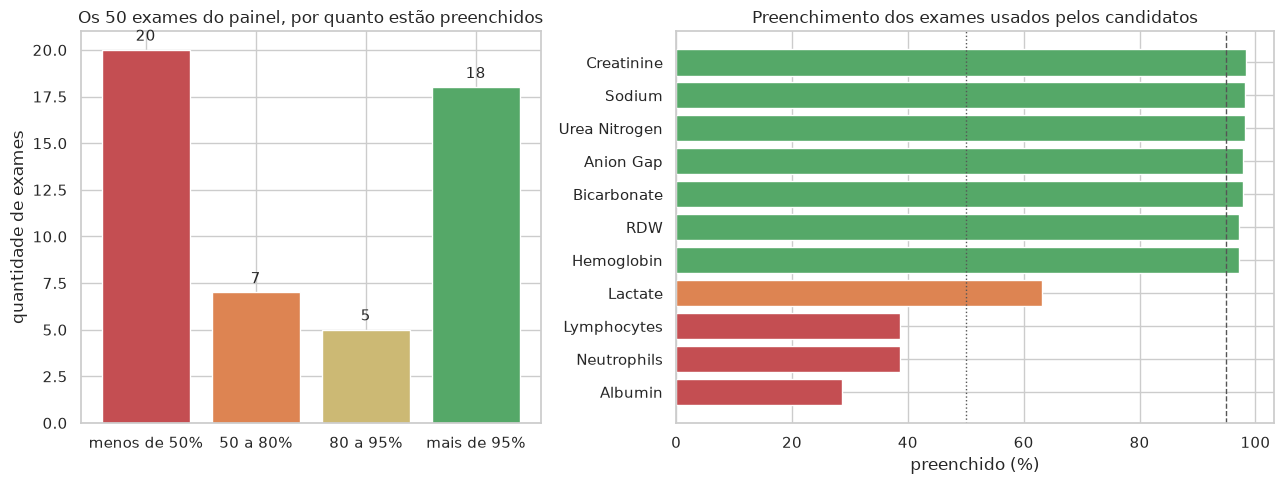

In [4]:
# O mesmo em forma de gráfico, que deixa a divisão em faixas mais visível.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.3]})

faixas = pd.cut(
    preenchimento["preenchido_%"],
    [0, 50, 80, 95, 100],
    labels=["menos de 50%", "50 a 80%", "80 a 95%", "mais de 95%"],
)
contagem = faixas.value_counts().sort_index()
ax1.bar(range(len(contagem)), contagem.values, color=["#c44e52", "#dd8452", "#ccb974", "#55a868"])
for i, valor in enumerate(contagem.values):
    ax1.text(i, valor + 0.5, str(valor), ha="center", fontsize=11)
ax1.set_xticks(range(len(contagem)))
ax1.set_xticklabels(contagem.index)
ax1.set_ylabel("quantidade de exames")
ax1.set_title("Os 50 exames do painel, por quanto estão preenchidos")

destaque = preenchimento.loc[preenchimento.index.intersection(interesse)].sort_values(
    "preenchido_%"
)
cor = np.where(
    destaque["preenchido_%"] >= 95,
    "#55a868",
    np.where(destaque["preenchido_%"] >= 50, "#dd8452", "#c44e52"),
)
ax2.barh(range(len(destaque)), destaque["preenchido_%"], color=cor)
ax2.axvline(95, color="#555", linestyle="--", linewidth=1)
ax2.axvline(50, color="#555", linestyle=":", linewidth=1)
ax2.set_yticks(range(len(destaque)))
ax2.set_yticklabels(destaque.index)
ax2.set_xlabel("preenchido (%)")
ax2.set_title("Preenchimento dos exames usados pelos candidatos")
plt.tight_layout()
plt.show()

> **O que isso mostra.** Os exames não se distribuem de forma suave: eles se agrupam em dois blocos. Dezoito exames passam de 95% de preenchimento e vinte ficam abaixo de 50%, com poucos no meio.
>
> Essa divisão espelha a rotina do hospital. O bloco cheio é o painel básico, colhido de todo paciente que chega: hemograma, eletrólitos, função renal. O bloco vazio depende de alguém decidir pedir.
>
> Repare onde cada exame cai. Ureia, creatinina, sódio, ânion gap, bicarbonato, RDW e hemoglobina ficam acima de 95%. O lactato fica em 63,2%. A albumina e o diferencial de leucócitos, que dão a razão neutrófilos/linfócitos, ficam abaixo de 50%.
>
> **Quanto mais à esquerda o exame estiver, mais a ausência dele significa alguma coisa.** É por isso que o lactato vai receber um tratamento especial mais adiante.

### 1.3 Valores extremos

Alguns exames têm valores muito altos. Glicose de 1.158 mg/dL, creatinina de 22,1 mg/dL. A primeira reação costuma ser suspeitar de erro de digitação e apagar esses casos.

**Apagar seria errado.** Numa UTI esses valores são reais: creatinina de 22 é insuficiência renal grave, não erro de digitação. E são justamente esses pacientes que o projeto quer identificar. Apagar os extremos seria apagar os casos mais graves, que é o contrário do objetivo.

Mas deixar como está também tem problema. Um único paciente com creatinina de 22, num grupo em que quase todo mundo está entre 1 e 2, pesa desproporcionalmente na hora de ajustar o modelo. Ele acaba mandando mais na conta do que os outros novecentos juntos.

A saída é **limitar sem apagar**, uma técnica chamada winsorização. Escolhemos dois pontos de corte: o valor abaixo do qual estão os 1% menores e o valor acima do qual estão os 1% maiores. Quem estiver fora é trazido para o corte mais próximo.

O paciente com creatinina de 22 continua na análise, continua sendo o caso mais grave do grupo, mas passa a contar como "9,3, o limite alto" em vez de 22. **Ninguém é removido; só o peso do extremo é contido.** Primeiro olhamos a amplitude de cada exame, depois aplicamos.

In [5]:
# Olha a amplitude dos principais exames: menor valor, valor do meio e maior valor.
principais = ["Urea Nitrogen", "Creatinine", "Lactate", "Anion Gap", "RDW", "Sodium"]
amplitude = painel[principais].describe().T[["min", "50%", "max"]]
amplitude.columns = ["menor", "mediana", "maior"]
amplitude["quantas vezes a mediana"] = (amplitude["maior"] / amplitude["mediana"]).round(1)
amplitude.round(2)

,menor,mediana,maior,quantas vezes a mediana
exame,,,,
Urea Nitrogen,3.0,28.5,203.0,7.1
Creatinine,0.4,1.3,22.1,17.0
Lactate,0.5,1.8,15.0,8.3
Anion Gap,4.0,14.0,48.0,3.4
RDW,11.9,15.3,29.3,1.9
Sodium,113.0,138.0,156.0,1.1


> **O que isso mostra.** Creatinina e ureia têm os maiores extremos: o maior valor é 17 e 7 vezes a mediana. Sódio e RDW quase não variam, porque o organismo controla essas medidas numa faixa estreita e sair dela já é doença grave.
>
> É nessa diferença de escala que o problema está. Num exame em que o maior valor é 17 vezes a mediana, um paciente isolado pesa mais que dezenas de outros na hora de ajustar o modelo. A célula seguinte aplica o limite.

In [ ]:
# Os exames e sinais vitais que entram em algum candidato. São esses que recebem
# o tratamento; Glasgow fica de fora porque a escala já é limitada de 3 a 15.
EXAMES_CANDIDATOS = [
    "Urea Nitrogen",
    "Creatinine",
    "RDW",
    "Anion Gap",
    "Bicarbonate",
    "Lactate",
    "Hemoglobin",
    "Sodium",
    "Neutrophils",
    "Lymphocytes",
    "Albumin",
]
VITAIS_CANDIDATOS = ["Systolic BP", "Heart Rate", "Respiratory Rate"]


def limitar_extremos(tabela, coluna_do_nome, quais, corte_baixo=0.01, corte_alto=0.99):
    """Traz os valores extremos de cada exame para dentro de um limite, sem remover ninguém.

    Para cada exame, calcula o valor abaixo do qual estão os 1% menores e o valor
    acima do qual estão os 1% maiores. Quem passar disso vira o próprio limite.

    Um paciente com creatinina de 22 continua na análise e continua sendo o caso
    mais grave; ele só deixa de puxar a conta sozinho. Devolve a tabela tratada e
    um relatório do que foi limitado em cada exame.
    """
    tabela = tabela.copy()
    relatorio = []

    for nome in quais:
        linhas = tabela[coluna_do_nome] == nome
        valores = tabela.loc[linhas, "valor"]
        if valores.notna().sum() == 0:
            continue

        limite_baixo = valores.quantile(corte_baixo)
        limite_alto = valores.quantile(corte_alto)
        fora = ((valores < limite_baixo) | (valores > limite_alto)).sum()

        relatorio.append(
            {
                "exame": nome,
                "menor original": round(valores.min(), 1),
                "limite baixo": round(limite_baixo, 1),
                "limite alto": round(limite_alto, 1),
                "maior original": round(valores.max(), 1),
                "medições": int(valores.notna().sum()),
                "limitadas": int(fora),
            }
        )

        # .clip() do pandas faz exatamente isso: tudo abaixo vira o limite de
        # baixo, tudo acima vira o limite de cima, e os ausentes seguem ausentes.
        tabela.loc[linhas, "valor"] = valores.clip(lower=limite_baixo, upper=limite_alto)

    return tabela, pd.DataFrame(relatorio)


# Guardamos as tabelas originais: a seção 6 refaz a análise sem o tratamento,
# para conferir se alguma conclusão dependia dele.
labs_original = labs.copy()
labs_series_original = labs_series.copy()
vitais_original = vitais.copy()

# O mesmo critério nos três lugares de onde saem os números da análise:
# o valor de admissão, a série do dia inteiro e os sinais vitais.
labs, limites_exames = limitar_extremos(labs, "exame", EXAMES_CANDIDATOS)
labs_series, _ = limitar_extremos(labs_series, "exame", EXAMES_CANDIDATOS)
vitais, limites_vitais = limitar_extremos(vitais, "sinal", VITAIS_CANDIDATOS)

# O painel foi montado antes do tratamento, então precisa ser refeito.
painel = labs.pivot(index="paciente_id", columns="exame", values="valor")

limites = pd.concat([limites_exames, limites_vitais], ignore_index=True)
limites["% limitado"] = (limites.limitadas / limites["medições"] * 100).round(2)

print(
    f"valores trazidos para dentro do limite: {limites.limitadas.sum():,} "
    f"de {limites['medições'].sum():,} medições "
    f"({limites.limitadas.sum() / limites['medições'].sum():.2%})"
)
print("internações removidas: 0 — nenhum paciente sai da análise")
limites

valores trazidos para dentro do limite: 1,630 de 88,197 medições (1.85%)
internações removidas: 0 — nenhum paciente sai da análise


,exame,menor original,limite baixo,limite alto,maior original,medições,limitadas,% limitado
0,Urea Nitrogen,3.0,8.0,129.8,203.0,982,17,1.73
1,Creatinine,0.4,0.5,9.3,22.1,983,17,1.73
2,RDW,11.9,12.3,23.9,29.3,971,18,1.85
3,Anion Gap,4.0,7.0,30.2,48.0,979,18,1.84
4,Bicarbonate,5.0,9.0,39.2,50.0,979,18,1.84
5,Lactate,0.5,0.7,11.5,15.0,632,12,1.90
6,Hemoglobin,4.5,6.0,15.7,17.9,971,18,1.85
7,Sodium,113.0,122.0,149.0,156.0,982,14,1.43
8,Neutrophils,1.0,33.8,94.6,96.4,386,8,2.07
9,Lymphocytes,0.0,0.8,44.9,63.6,386,8,2.07


> **O que isso mostra.** O tratamento alcançou 1.630 valores de 88.197 medições, 1,85% do total. É pouco por construção: a regra só pega os 1% de cada ponta de cada exame. E a última coluna mostra que a proporção ficou entre 1,1% e 2,1% em todos eles, o que confirma que nenhum exame foi tratado de forma diferente dos outros.
>
> A coluna que importa é a distância entre "maior original" e "limite alto". Na **creatinina** o maior valor da coorte era 22,1 e passa a contar como 9,3. O paciente continua na análise e continua sendo o caso renal mais grave do grupo; ele só deixa de pesar sozinho mais que dezenas de outros quando o modelo é ajustado. Na **ureia** o 203 vira 129,8, e na **pressão sistólica** o 233 vira 177.
>
> Repare que a contagem é dominada pelos sinais vitais: eles somam quase 1.500 dos 1.630 valores limitados. Não é porque são mais extremos, é porque são medidos dezenas de vezes por dia, enquanto cada exame de sangue aparece uma vez por internação. A **albumina** está no outro extremo, com 3 valores limitados, simplesmente porque foi dosada em poucos pacientes.
>
> O tratamento vale nos três lugares de onde saem os números da análise: o valor de admissão, a série do dia inteiro, que alimenta a seção 3, e os sinais vitais. Usar um critério aqui e outro ali seria uma inconsistência difícil de defender.
>
> A partir daqui toda a análise usa os valores limitados. A **seção 6.4** refaz as contas com os valores originais e responde à única pergunta que interessa: algum veredicto muda por causa dessa escolha?

## 2 Operacionalizando os biomarcadores candidatos

Na Entrega 1, um candidato era uma ideia clínica, como "ureia de admissão". Para entrar numa análise, ele precisa virar uma coluna de tabela com um número por internação. Essa tradução é o que chamamos de operacionalizar.

Fazemos isso de três formas.

**Valor de chegada.** A primeira medida registrada dentro das 24 horas. É o que o médico tem na mão quando precisa decidir. Poderíamos usar a média do dia inteiro, mas isso seria trapaça: estaríamos usando informação que ainda não existia na hora da decisão.

**Contas combinando exames.** A razão ureia/creatinina e a razão neutrófilos/linfócitos, propostas pela equipe na Entrega 1.

**Sim ou não, usando cortes da literatura.** Por exemplo, ureia acima de 43 mg/dL. Testar esses cortes aqui é uma verificação independente: se um limiar que funcionou noutro hospital continua funcionando neste, ele provavelmente reflete algo real.

In [7]:
def primeiro_valor(tabela, coluna_nome):
    """Pega a primeira medida de cada exame ou sinal vital dentro da janela de 24h.

    A tabela vem com várias linhas por internação (uma por medição). Ordenamos
    pela hora e ficamos com a primeira de cada tipo.
    """
    return (
        tabela.sort_values("horas_da_janela")
        .groupby(["paciente_id", coluna_nome])
        .valor.first()
        .unstack()
    )


# EXAMES_CANDIDATOS e VITAIS_CANDIDATOS foram definidos na seção 1.3, onde
# receberam o tratamento de valores extremos.
# Começa com os dados do paciente e vai acrescentando colunas.
X = coorte.join(painel[EXAMES_CANDIDATOS])
X = X.join(primeiro_valor(vitais, "sinal")[VITAIS_CANDIDATOS])

# Glasgow: o valor na chegada e o pior valor do dia.
por_internacao = gcs.sort_values("horas_da_janela").groupby("paciente_id")
X["gcs_admissao"] = por_internacao["GCS total"].first()
X["gcs_minimo"] = por_internacao["GCS total"].min()

# Pressão arterial: registramos se veio de cateter ou de manguito, porque
# a escolha do método pode dizer algo sobre a gravidade percebida.
pressao = vitais[vitais.sinal == "Systolic BP"].sort_values("horas_da_janela")
X["origem_pressao"] = pressao.groupby("paciente_id").origem.first()

print(f"colunas até aqui: {X.shape[1]}")

colunas até aqui: 20


In [8]:
# As duas contas propostas pela equipe na Entrega 1.
X["razao_ureia_creatinina"] = X["Urea Nitrogen"] / X["Creatinine"]

# Se o paciente tem zero linfócitos, a divisão não faz sentido: marcamos como ausente.
X["razao_neutrofilos_linfocitos"] = X["Neutrophils"] / X["Lymphocytes"].where(X["Lymphocytes"] > 0)

# Ânion gap corrigido pela albumina. A albumina "esconde" parte da acidez,
# então quando ela está baixa o ânion gap medido subestima o problema.
# A fórmula é usada na prática clínica.
X["anion_gap_corrigido"] = X["Anion Gap"] + 2.5 * (4.0 - X["Albumin"])

# As perguntas de sim ou não, usando os cortes da literatura.
# Se o exame não foi feito, a resposta fica ausente em vez de virar "não".
for nome, exame, corte, acima_e_pior in [
    ("ureia_alta", "Urea Nitrogen", CORTE_UREIA, True),
    ("rdw_alto", "RDW", CORTE_RDW, True),
    ("sodio_baixo", "Sodium", CORTE_SODIO, False),
    ("pressao_baixa", "Systolic BP", CORTE_PRESSAO, False),
]:
    X[nome] = (X[exame] >= corte if acima_e_pior else X[exame] < corte).astype(float)
    X.loc[X[exame].isna(), nome] = np.nan

# Marca quem teve o exame pedido. Como vimos, isso carrega informação clínica.
X["pediram_lactato"] = X["Lactate"].notna().astype(int)
X["pediram_diferencial"] = X["razao_neutrofilos_linfocitos"].notna().astype(int)

CANDIDATOS = [
    "Urea Nitrogen",
    "razao_ureia_creatinina",
    "Creatinine",
    "RDW",
    "Anion Gap",
    "Bicarbonate",
    "Lactate",
    "razao_neutrofilos_linfocitos",
    "Hemoglobin",
    "Sodium",
    "Systolic BP",
    "Heart Rate",
    "Respiratory Rate",
]

pd.DataFrame(
    {
        "preenchido_%": (
            X[CANDIDATOS + REFERENCIA + ["anion_gap_corrigido"]].notna().mean() * 100
        ).round(1)
    }
).sort_values("preenchido_%", ascending=False).T

,Respiratory Rate,idade,Heart Rate,gcs_admissao,Systolic BP,Creatinine,razao_ureia_creatinina,Urea Nitrogen,Sodium,Anion Gap,Bicarbonate,RDW,Hemoglobin,Lactate,razao_neutrofilos_linfocitos,anion_gap_corrigido
preenchido_%,100.0,100.0,100.0,99.6,99.2,98.3,98.2,98.2,98.2,97.9,97.9,97.1,97.1,63.2,38.6,28.7


> **O que isso mostra.** Onze dos treze candidatos passam de 95% de preenchimento, então valem para quase toda a coorte. O lactato fica em 63,2% e a razão neutrófilos/linfócitos em 38,6%.
>
> O ânion gap corrigido só existe em 28,7% das internações, porque depende da albumina. É pouco para ser a análise principal, mas dá para usá-lo como verificação na seção 6, que foi exatamente o que a Entrega 1 propôs.

## 3 Características temporais: o candidato K

Até aqui usamos só o primeiro valor de cada exame. Mas muitos exames foram repetidos ao longo das 24 horas, e essa repetição carrega informação que um valor isolado não tem.

A Entrega 1 previu isso e propôs cinco resumos por exame. Cada um responde a uma pergunta diferente:

- **média**: qual foi o nível típico do dia?
- **mínimo** e **máximo**: qual foi o pior momento? Para o bicarbonato o perigo é cair, para o lactato é subir
- **amplitude** (maior menos menor): o paciente ficou instável?
- **variação** (último menos primeiro): terminou o dia melhor ou pior do que começou?

In [9]:
EXAMES_REPETIDOS = [
    "Urea Nitrogen",
    "Creatinine",
    "RDW",
    "Anion Gap",
    "Bicarbonate",
    "Lactate",
    "Hemoglobin",
    "Sodium",
]

# Fica só com os exames que nos interessam e ordena por hora.
serie = labs_series[labs_series.exame.isin(EXAMES_REPETIDOS)].sort_values("horas_da_janela")
grupos = serie.groupby(["paciente_id", "exame"])

# Os cinco resumos. Os três primeiros são funções prontas do pandas.
resumos = grupos.valor.agg(media="mean", minimo="min", maximo="max")
resumos["amplitude"] = resumos.maximo - resumos.minimo

# Variação: último valor menos o primeiro. Positivo = subiu durante o dia.
primeiro = grupos.valor.first()
ultimo = grupos.valor.last()
resumos["variacao"] = ultimo - primeiro

# Reorganiza para uma coluna por exame e resumo, com nomes como "Lactate__minimo".
resumos = resumos.unstack()
resumos.columns = [f"{exame}__{resumo}" for resumo, exame in resumos.columns]

X = X.join(resumos.sort_index(axis=1))
colunas_temporais = [c for c in X.columns if "__" in c]

quantas = serie.groupby(["paciente_id", "exame"]).size()
print(
    f"colunas temporais criadas: {len(colunas_temporais)} "
    f"({len(EXAMES_REPETIDOS)} exames × 5 resumos)"
)
print(
    f"medições por exame em cada internação: mediana {int(quantas.median())}, "
    f"máximo {quantas.max()}"
)
print(f"casos com pelo menos duas medições: {(quantas >= 2).mean():.1%}")
print(f"tabela final: {X.shape[0]} internações × {X.shape[1]} colunas")

colunas temporais criadas: 40 (8 exames × 5 resumos)
medições por exame em cada internação: mediana 2, máximo 14
casos com pelo menos duas medições: 71.1%
tabela final: 1000 internações × 69 colunas


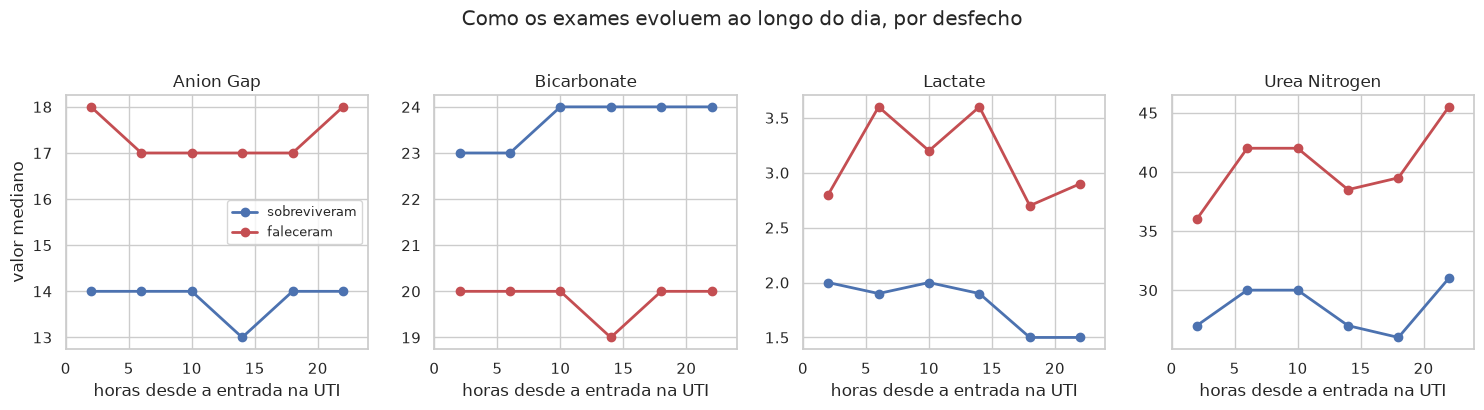

In [10]:
# Como as medidas evoluem ao longo do dia, separando quem sobreviveu de quem faleceu.
EXAMES_GRAFICO = ["Anion Gap", "Bicarbonate", "Lactate", "Urea Nitrogen"]
desfecho = coorte[OUTCOME]
faixas_hora = pd.IntervalIndex.from_breaks([0, 4, 8, 12, 16, 20, 24])

fig, eixos = plt.subplots(1, 4, figsize=(15, 4))
for eixo, exame in zip(eixos, EXAMES_GRAFICO, strict=True):
    dados = labs_series[labs_series.exame == exame].copy()
    dados["faixa"] = pd.cut(dados.horas_da_janela, faixas_hora)
    dados["faleceu"] = dados.paciente_id.map(desfecho)
    # Mediana de cada faixa de 4 horas, separada por desfecho.
    medianas = dados.groupby(["faixa", "faleceu"], observed=True).valor.median().unstack()
    centros = [intervalo.mid for intervalo in medianas.index]
    for coluna, cor, rotulo in [(False, "#4c72b0", "sobreviveram"), (True, "#c44e52", "faleceram")]:
        if coluna in medianas:
            eixo.plot(centros, medianas[coluna], marker="o", color=cor, linewidth=2, label=rotulo)
    eixo.set_title(exame)
    eixo.set_xlabel("horas desde a entrada na UTI")
    eixo.set_xlim(0, 24)
eixos[0].set_ylabel("valor mediano")
eixos[0].legend(fontsize=9)
fig.suptitle("Como os exames evoluem ao longo do dia, por desfecho", y=1.02)
plt.tight_layout()
plt.show()

> **O que isso mostra.** As duas linhas já começam separadas e continuam assim o dia inteiro. Não é que quem faleceu tenha piorado ao longo das 24 horas enquanto os outros melhoravam: os dois grupos **partem de patamares diferentes e seguem em paralelo**.
>
> Isso tem uma consequência prática. Significa que o valor que interessa é o **nível** em que o paciente está, e não a velocidade com que ele muda. A seção 5 confirma isso: nos candidatos que funcionam, quem vence é a média ou o mínimo, nunca a variação do dia.
>
> O lactato é o mais irregular dos quatro, e a explicação é simples: ele foi medido em menos pacientes e menos vezes, então cada ponto da linha se apoia em menos gente.
>
> Um cuidado ao ler: cada faixa de horas usa quem tinha medição naquele intervalo, então o conjunto de pacientes muda ao longo do eixo. As linhas descrevem o grupo, não a trajetória de um paciente específico.

## 4 Análise estatística e associações com mortalidade

Agora comparamos quem faleceu com quem sobreviveu. A pergunta é direta: **os valores são diferentes entre os dois grupos?**

### 4.1 Comparando os grupos

Usamos a **mediana** em vez da média. A mediana é o valor do meio: metade dos pacientes está acima, metade abaixo. Ela é mais adequada aqui porque alguns exames têm valores muito altos que puxariam a média para cima sem representar o paciente típico.

Para saber se a diferença é grande o bastante, usamos o **teste de Mann-Whitney**. Ele responde: "se essa diferença fosse só sorte, qual a chance de eu ver algo assim?". Essa chance é o **valor-p**. Quanto menor, menos provável que seja coincidência. O limite usual é 0,05, ou seja, 5%.

Há um detalhe. Estamos testando treze candidatos de uma vez, e testando muita coisa, alguma dá "significativa" por acaso. A **correção de Benjamini-Hochberg** ajusta os valores-p para isso. O resultado corrigido aparece na coluna `p corrigido`.

In [11]:
def comparar_grupos(tabela, variavel):
    """Compara o valor de uma variável entre quem faleceu e quem sobreviveu."""
    dados = tabela[[variavel, OUTCOME]].dropna()
    sobreviveram = dados.loc[~dados[OUTCOME], variavel]
    faleceram = dados.loc[dados[OUTCOME], variavel]

    # Mann-Whitney: compara as distribuições sem supor que sejam "normais".
    p = stats.mannwhitneyu(faleceram, sobreviveram, alternative="two-sided").pvalue

    return {
        "candidato": variavel,
        "n": len(dados),
        "mediana sobreviveram": round(sobreviveram.median(), 2),
        "mediana faleceram": round(faleceram.median(), 2),
        "diferença": round(faleceram.median() - sobreviveram.median(), 2),
        "p": p,
    }


def corrigir_multiplos_testes(valores_p):
    """Correção de Benjamini-Hochberg.

    Como testamos treze candidatos, alguns valores-p pequenos apareceriam por
    acaso. Esta correção torna a exigência mais rigorosa conforme o número de
    testes, devolvendo um valor-p ajustado.
    """
    p = np.asarray(valores_p, dtype=float)
    n = len(p)
    ajustado = np.empty(n)
    menor_ate_agora = 1.0
    # Percorre do maior p para o menor, aplicando o fator de correção.
    for posicao, indice in enumerate(np.argsort(p)[::-1]):
        menor_ate_agora = min(menor_ate_agora, p[indice] * n / (n - posicao))
        ajustado[indice] = menor_ate_agora
    return ajustado


comparacao = pd.DataFrame([comparar_grupos(X, c) for c in CANDIDATOS])
comparacao["p corrigido"] = corrigir_multiplos_testes(comparacao.p)
comparacao["separa os grupos"] = comparacao["p corrigido"] < 0.05
comparacao = comparacao.sort_values("p")

comparacao.assign(
    p=lambda d: d.p.map("{:.1e}".format),
    **{"p corrigido": lambda d: d["p corrigido"].map("{:.1e}".format)},
)

,candidato,n,mediana sobreviveram,mediana faleceram,diferença,p,p corrigido,separa os grupos
4,Anion Gap,979,14.00,17.00,3.00,3.5e-11,4.6e-10,True
5,Bicarbonate,979,24.00,21.00,-3.00,4.2e-09,2.6e-08,True
3,RDW,971,15.10,16.50,1.40,6.1e-09,2.6e-08,True
0,Urea Nitrogen,982,27.00,37.00,10.00,7.8e-08,2.5e-07,True
2,Creatinine,983,1.20,1.70,0.50,1.4e-06,3.5e-06,True
6,Lactate,632,1.80,2.10,0.30,1.6e-06,3.5e-06,True
10,Systolic BP,992,120.00,111.00,-9.00,4.7e-05,8.8e-05,True
11,Heart Rate,1000,85.00,92.00,7.00,9.9e-05,1.6e-04,True
7,razao_neutrofilos_linfocitos,386,8.17,9.52,1.35,1.0e-01,1.4e-01,False
12,Respiratory Rate,1000,19.00,20.00,1.00,1.1e-01,1.4e-01,False


> **O que isso mostra.** Oito dos treze candidatos separam os grupos, e as diferenças fazem sentido clínico.
>
> O **ânion gap** vai de 14 para 17, ou seja, o sangue de quem faleceu estava mais ácido. O **bicarbonato** cai de 24 para 21, que é a outra face da mesma acidez. A **ureia** sobe de 27 para 37 e a **creatinina** de 1,2 para 1,7, mostrando pior função renal. A **pressão sistólica** cai de 120 para 111 e a **frequência cardíaca** sobe de 85 para 92, que é o coração tentando compensar.
>
> Todas as diferenças vão na direção que a fisiologia prevê. Isso é uma verificação importante: se algum exame apontasse para o lado contrário, o mais provável seria erro na construção da variável, e não uma descoberta.
>
> Cinco candidatos não separam. O **sódio** tem mediana 138 nos dois grupos, exatamente igual. A **hemoglobina** varia de 10,0 para 9,9, o que é nada. E a **razão ureia/creatinina** não separa, apesar de a ureia e a creatinina separarem cada uma por si. A seção 4.3 explica por quê.

### 4.2 Os cortes da literatura funcionam nesta coorte?

Em vez de comparar valores contínuos, aqui dividimos os pacientes em dois grupos usando limiares já publicados, e comparamos a mortalidade de cada lado.

Usamos o **teste exato de Fisher** e a **razão de chances**, que responde: quantas vezes mais chance de falecer tem quem está acima do corte? Um valor de 2 significa o dobro da chance. Um valor perto de 1 significa que o corte não separa nada.

In [12]:
def comparar_corte(tabela, variavel):
    """Compara a mortalidade de quem está acima e abaixo de um corte."""
    dados = tabela[[variavel, OUTCOME]].dropna()
    cruzamento = pd.crosstab(dados[variavel], dados[OUTCOME])
    razao_chances, p = stats.fisher_exact(cruzamento.to_numpy())
    return {
        "corte": variavel,
        "n": len(dados),
        "razão de chances": round(razao_chances, 2),
        "mortalidade acima do corte": f"{dados.loc[dados[variavel] == 1, OUTCOME].mean():.1%}",
        "mortalidade abaixo": f"{dados.loc[dados[variavel] == 0, OUTCOME].mean():.1%}",
        "p": p,
    }


CORTES = [
    "ureia_alta",
    "rdw_alto",
    "sodio_baixo",
    "pressao_baixa",
    "pediram_lactato",
    "pediram_diferencial",
]
tabela_cortes = pd.DataFrame([comparar_corte(X, c) for c in CORTES])
tabela_cortes["p corrigido"] = corrigir_multiplos_testes(tabela_cortes.p)
tabela_cortes.sort_values("razão de chances", ascending=False).assign(
    p=lambda d: d.p.map("{:.1e}".format),
    **{"p corrigido": lambda d: d["p corrigido"].map("{:.1e}".format)},
)

,corte,n,razão de chances,mortalidade acima do corte,mortalidade abaixo,p,p corrigido
4,pediram_lactato,1000,2.68,20.9%,9.0%,5.9e-07,1.9e-06
1,rdw_alto,971,2.57,21.0%,9.4%,6.4e-07,1.9e-06
0,ureia_alta,982,2.06,23.5%,12.9%,6.3e-05,1.3e-04
3,pressao_baixa,992,1.53,19.3%,13.5%,1.5e-02,2.3e-02
2,sodio_baixo,982,1.11,17.3%,15.8%,6.6e-01,6.6e-01
5,pediram_diferencial,1000,0.89,15.5%,17.1%,5.4e-01,6.5e-01


> **O que isso mostra.** Três dos quatro cortes da literatura funcionam aqui.
>
> **Ureia acima de 43 mg/dL**, que é o corte do registro ADHERE: a mortalidade passa de 12,9% para 23,5%, quase o dobro. **RDW acima de 14,96%**, de um estudo feito no próprio MIMIC-IV: de 9,4% para 21,0%. **Pressão sistólica abaixo de 115 mmHg**, também do ADHERE: de 13,5% para 19,3%.
>
> A **hiponatremia** não funciona: 17,3% contra 15,8%, praticamente igual. Coerente com o sódio contínuo também não ter separado.
>
> Mas o resultado que mais chama atenção é outro. **"Pediram lactato" tem a maior razão de chances de todas: 2,68.** Ou seja, saber que o médico pediu o exame prevê melhor do que o resultado do exame.
>
> Isso não é um achado sobre o paciente, é um achado sobre o hospital. O médico pede gasometria quando desconfia que o caso é grave, e ele costuma estar certo. Um modelo que usasse essa informação estaria aprendendo a copiar o julgamento médico, não a medir o doente. É por isso que essa variável **nunca** entra como preditor, e é por isso que o lactato precisa de cuidado extra.

### 4.3 Candidatos que medem a mesma coisa

Antes de montar modelos, vale verificar se alguns candidatos são redundantes. Se dois exames medem quase a mesma coisa, usar os dois não acrescenta nada.

A **correlação** mede isso numa escala de −1 a +1. Perto de +1, as duas medidas sobem juntas. Perto de −1, quando uma sobe a outra desce. Perto de 0, são independentes.

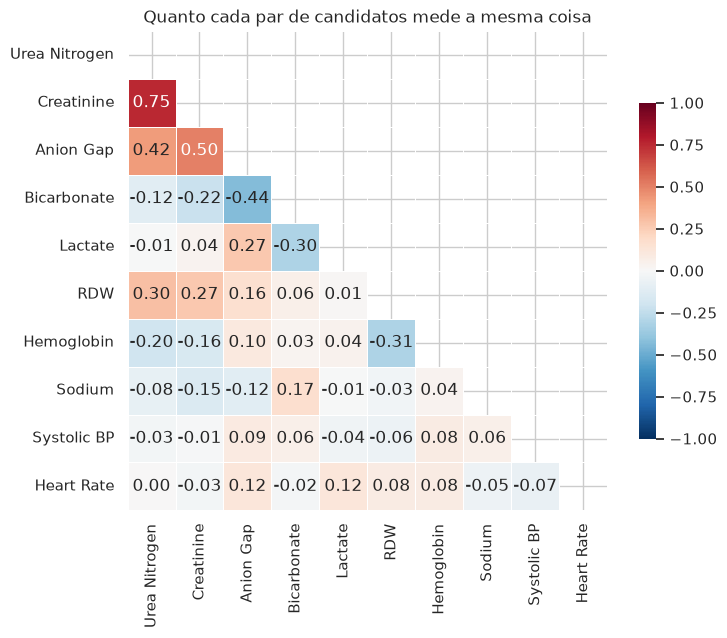

os pares mais parecidos entre si:
  Creatinine       e Urea Nitrogen    +0.75
  Anion Gap        e Creatinine       +0.50
  Bicarbonate      e Anion Gap        -0.44
  Anion Gap        e Urea Nitrogen    +0.42
  Hemoglobin       e RDW              -0.31


In [13]:
PARA_CORRELACIONAR = [
    "Urea Nitrogen",
    "Creatinine",
    "Anion Gap",
    "Bicarbonate",
    "Lactate",
    "RDW",
    "Hemoglobin",
    "Sodium",
    "Systolic BP",
    "Heart Rate",
]
correlacao = X[PARA_CORRELACIONAR].corr(method="spearman")

fig, eixo = plt.subplots(figsize=(8, 6.5))
mascara = np.triu(np.ones_like(correlacao, dtype=bool))  # esconde a metade repetida
sns.heatmap(
    correlacao,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    ax=eixo,
)
eixo.set_title("Quanto cada par de candidatos mede a mesma coisa")
plt.tight_layout()
plt.show()

print("os pares mais parecidos entre si:")
pares = (
    correlacao.where(~mascara)
    .melt(ignore_index=False)
    .dropna()
    .set_index("variable", append=True)
    .value.sort_values(key=abs, ascending=False)
)
for (a, b), valor in pares.head(5).items():
    print(f"  {a:16} e {b:16} {valor:+.2f}")

> **O que isso mostra.** Ureia e creatinina têm correlação de 0,75, a mais alta do quadro. Faz sentido: os dois medem função renal.
>
> E isso explica por que a **razão ureia/creatinina falhou**. A Entrega 1 propôs essa razão argumentando que ela separaria o efeito hormonal do efeito renal. Mas quando o numerador e o denominador sobem e descem juntos, a divisão de um pelo outro fica quase constante, e o resultado perde a informação que cada um carregava sozinho.
>
> O par ânion gap e bicarbonato dá −0,44, negativo como esperado, já que quando a acidez sobe o bicarbonato é consumido. É correlação média, não redundância: os dois ainda carregam informação distinta.
>
> O **RDW** não passa de correlação fraca com nenhum marcador de circulação. Ele mede outra coisa, o que sugere que pode acrescentar informação independente. A próxima seção confirma.

## 5 Modelagem computacional

Até aqui olhamos um candidato por vez. Mas a pergunta que importa é outra: **o exame acrescenta alguma coisa ao que o médico já sabia?**

Um exemplo torna isso claro. Suponha que pacientes mais velhos morram mais, e que pacientes mais velhos também tenham creatinina mais alta. Nesse caso a creatinina vai parecer associada à morte, mas pode estar só refletindo a idade. Para saber se ela acrescenta, precisamos comparar dois modelos.

**Modelo de referência:** tenta prever o óbito usando só idade e Glasgow, que é o que está disponível antes de qualquer exame chegar.

**Modelo com o candidato:** o mesmo, mais o exame.

Se o segundo prevê melhor que o primeiro, o exame acrescentou. Se não, ele só repetia o que já se sabia.

### 5.1 Como medimos "prever melhor"

Usamos a **AUC**, que é a área sob a curva ROC. Ela tem uma leitura direta: sorteando um paciente que faleceu e um que sobreviveu, qual a chance de o modelo dar risco maior ao que faleceu?

- AUC de 0,5 é o mesmo que jogar moeda
- AUC de 0,70 significa acertar a ordem em 70% dos pares
- AUC de 1,0 seria acertar sempre

Há um cuidado importante. Se treinarmos e avaliarmos o modelo nos mesmos pacientes, o resultado sai otimista, porque o modelo já viu aquelas respostas. Para evitar isso usamos **validação cruzada**: dividimos os pacientes em cinco partes, treinamos em quatro e avaliamos na quinta, repetindo cinco vezes. Assim cada paciente é avaliado por um modelo que nunca o viu.

In [14]:
def auc_do_modelo(tabela, colunas):
    """Treina uma regressão logística e devolve a AUC por validação cruzada.

    Usa só as internações que têm todas as colunas preenchidas.
    """
    dados = tabela[colunas + [OUTCOME]].dropna()
    particoes = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    notas = cross_val_score(
        LogisticRegression(max_iter=2000),
        dados[colunas].astype(float),
        dados[OUTCOME].astype(int),
        cv=particoes,
        scoring="roc_auc",
    )
    return {"n": len(dados), "AUC": round(notas.mean(), 3), "variação": round(notas.std(), 3)}


referencia = auc_do_modelo(X, REFERENCIA)
print("Modelo de referência: idade + Glasgow")
print(f"  internações usadas: {referencia['n']}")
print(f"  AUC: {referencia['AUC']} (variação entre as partições: {referencia['variação']})")

Modelo de referência: idade + Glasgow
  internações usadas: 996
  AUC: 0.672 (variação entre as partições: 0.056)


> **O que isso mostra.** Só com idade e Glasgow, o modelo acerta a ordenação em 67,2% dos pares. É pouco, e é honesto que seja pouco: idade e nível de consciência são informações grosseiras diante de tudo que acontece numa UTI.
>
> Mas é um ponto de partida justo, porque não exige nenhum exame. É contra esse patamar que cada candidato vai ser medido.

### 5.2 Quanto cada candidato acrescenta

Para cada candidato, treinamos dois modelos **nos mesmos pacientes**: um só com idade e Glasgow, outro com o candidato junto. A diferença entre as duas AUC é o ganho.

Comparar nos mesmos pacientes é essencial. Se o modelo com lactato rodasse só em quem fez gasometria, e o de referência em todo mundo, a comparação não valeria nada: as diferenças poderiam vir dos pacientes, não do exame.

In [15]:
def ganho_do_candidato(tabela, candidato):
    """Mede quanto a AUC melhora ao acrescentar um candidato à referência."""
    # Só as internações que têm referência e candidato preenchidos.
    dados = tabela[REFERENCIA + [candidato, OUTCOME]].dropna()
    if len(dados) < 50:
        return None

    sem_candidato = auc_do_modelo(dados, REFERENCIA)
    com_candidato = auc_do_modelo(dados, REFERENCIA + [candidato])

    return {
        "candidato": candidato,
        "n": len(dados),
        "AUC sem": sem_candidato["AUC"],
        "AUC com": com_candidato["AUC"],
        "ganho": round(com_candidato["AUC"] - sem_candidato["AUC"], 4),
    }


ganhos = pd.DataFrame([g for g in (ganho_do_candidato(X, c) for c in CANDIDATOS) if g])

# Junta com a comparação de grupos da seção 4.1, para aplicar o critério completo.
resultado = ganhos.merge(
    comparacao[["candidato", "p corrigido", "separa os grupos"]], on="candidato"
)

# O CRITÉRIO, definido antes de olhar os resultados:
# o candidato precisa separar os grupos E melhorar a AUC em pelo menos 1 ponto.
resultado["melhora a previsão"] = resultado["ganho"] >= 0.01
resultado["sustentado"] = resultado["separa os grupos"] & resultado["melhora a previsão"]
resultado = resultado.sort_values("ganho", ascending=False)

resultado[
    [
        "candidato",
        "n",
        "AUC sem",
        "AUC com",
        "ganho",
        "separa os grupos",
        "melhora a previsão",
        "sustentado",
    ]
]

,candidato,n,AUC sem,AUC com,ganho,separa os grupos,melhora a previsão,sustentado
3,RDW,970,0.648,0.728,0.080,True,True,True
4,Anion Gap,977,0.653,0.725,0.072,True,True,True
6,Lactate,630,0.617,0.671,0.054,True,True,True
5,Bicarbonate,977,0.653,0.690,0.037,True,True,True
0,Urea Nitrogen,980,0.650,0.687,0.037,True,True,True
10,Systolic BP,988,0.661,0.688,0.027,True,True,True
2,Creatinine,981,0.651,0.667,0.016,True,True,True
11,Heart Rate,996,0.672,0.685,0.013,True,True,True
1,razao_ureia_creatinina,980,0.650,0.652,0.002,False,False,False
7,razao_neutrofilos_linfocitos,385,0.664,0.665,0.001,False,False,False


> **O que isso mostra.** Oito candidatos passam nas duas perguntas.
>
> **RDW** e **ânion gap** lideram, com ganhos de 0,080 e 0,072. São cerca de oito e sete pontos de AUC, obtidos de exames que já vêm no hemograma e na bioquímica de rotina.
>
> Depois vêm lactato, bicarbonato, ureia, pressão sistólica, creatinina e frequência cardíaca, com ganhos menores mas ainda acima de um ponto.
>
> Cinco candidatos não passam. **Sódio, frequência respiratória, razão ureia/creatinina, razão neutrófilos/linfócitos e hemoglobina** ficam abaixo de um ponto de ganho, e são exatamente os cinco que já não haviam separado os grupos na seção 4. As duas perguntas concordaram em todos os treze candidatos.
>
> Vale reparar num detalhe: a **creatinina passa, mas raspando**. Ela separa bem os grupos, porém acrescenta pouco mais de um ponto ao modelo, no limite do mínimo exigido. A explicação está na seção 4.3: como ela correlaciona 0,75 com a ureia, boa parte do que ela traz a ureia já trouxe.

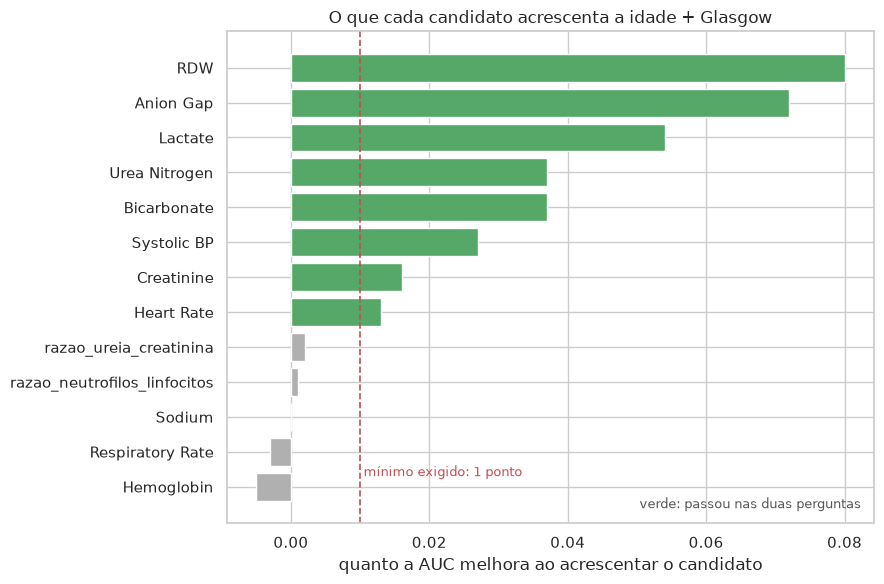

In [16]:
fig, eixo = plt.subplots(figsize=(9, 6))
d = resultado.sort_values("ganho")
cores = np.where(d.sustentado, "#55a868", "#b0b0b0")
eixo.barh(range(len(d)), d.ganho, color=cores)
eixo.axvline(0.01, color="#c44e52", linestyle="--", linewidth=1.2)
eixo.text(0.0105, 0.3, "mínimo exigido: 1 ponto", fontsize=9, color="#c44e52")
eixo.set_yticks(range(len(d)))
eixo.set_yticklabels(d.candidato)
eixo.set_xlabel("quanto a AUC melhora ao acrescentar o candidato")
eixo.set_title("O que cada candidato acrescenta a idade + Glasgow")
eixo.text(
    0.98,
    0.03,
    "verde: passou nas duas perguntas",
    transform=eixo.transAxes,
    fontsize=9,
    color="#555",
    ha="right",
)
plt.tight_layout()
plt.show()

> **O que isso mostra.** O gráfico deixa visível a separação entre os grupos. Há um bloco claro no topo, com RDW e ânion gap bem acima dos demais, e um bloco embaixo colado no zero.
>
> A linha vermelha marca o mínimo exigido de um ponto. Esse limite é uma escolha nossa, não uma regra universal, e foi fixada antes de ver os números. A ideia por trás dela: um ganho menor que um ponto de AUC dificilmente muda alguma decisão na prática, mesmo que exista.

### 5.3 O valor de chegada ou a evolução do dia?

O candidato K perguntava se os resumos das 24 horas discriminam melhor que a primeira medida. Aqui testamos isso: para cada exame, comparamos o ganho do valor de chegada com o ganho de cada resumo da janela.

In [17]:
RESUMOS = ["media", "minimo", "maximo", "amplitude", "variacao"]
comparacao_temporal = []

for exame in EXAMES_REPETIDOS:
    inicial = ganho_do_candidato(X, exame)
    if inicial is None:
        continue

    melhor_ganho = inicial["ganho"]
    melhor_resumo = "valor de chegada"

    # Testa cada um dos cinco resumos e guarda o melhor.
    for resumo in RESUMOS:
        coluna = f"{exame}__{resumo}"
        if coluna not in X.columns:
            continue
        candidato = ganho_do_candidato(X, coluna)
        if candidato and candidato["ganho"] > melhor_ganho:
            melhor_ganho = candidato["ganho"]
            melhor_resumo = resumo

    comparacao_temporal.append(
        {
            "exame": exame,
            "ganho do valor de chegada": inicial["ganho"],
            "melhor resumo do dia": melhor_resumo,
            "ganho do melhor resumo": melhor_ganho,
            "diferença": round(melhor_ganho - inicial["ganho"], 4),
        }
    )

tabela_temporal = pd.DataFrame(comparacao_temporal).sort_values("diferença", ascending=False)
quantos = (tabela_temporal["melhor resumo do dia"] != "valor de chegada").sum()
print(
    f"em {quantos} de {len(tabela_temporal)} exames, um resumo do dia "
    f"discrimina melhor que o valor de chegada"
)
tabela_temporal

em 8 de 8 exames, um resumo do dia discrimina melhor que o valor de chegada


,exame,ganho do valor de chegada,melhor resumo do dia,ganho do melhor resumo,diferença
5,Lactate,0.054,minimo,0.087,0.033
4,Bicarbonate,0.037,minimo,0.067,0.030
3,Anion Gap,0.072,media,0.093,0.021
7,Sodium,0.000,variacao,0.011,0.011
0,Urea Nitrogen,0.037,maximo,0.046,0.009
1,Creatinine,0.016,maximo,0.022,0.006
6,Hemoglobin,-0.005,variacao,0.001,0.006
2,RDW,0.080,media,0.082,0.002


> **O que isso mostra.** A previsão do candidato K se confirma: nos oito exames repetidos, sem exceção, algum resumo do dia funciona melhor que a primeira medida.
>
> Os maiores ganhos estão no **lactato** e no **bicarbonato**, e nos dois casos o resumo vencedor é o **mínimo**. Isso faz sentido clínico: para o bicarbonato, o perigo está em quanto ele chegou a cair; a primeira medida pode pegar o paciente antes da queda.
>
> No **ânion gap** vence a **média**, o que também é coerente: ali o que importa é o nível em que o paciente se manteve, não um pico isolado.
>
> A **variação** ao longo do dia só vence em sódio e hemoglobina, que são justamente os dois exames cujo valor de chegada não acrescentava nada. Nos candidatos que de fato funcionam, quem vence é a média ou o mínimo. Isso confirma o que o gráfico da seção 3 sugeria: o sinal está no patamar em que o paciente se mantém, não na velocidade com que ele muda.
>
> **Uma ressalva importante.** Para cada exame testamos seis opções e reportamos a melhor. Escolher a melhor entre seis e depois mostrar só ela deixa o resultado mais bonito do que ele é, porque a escolha usou os mesmos dados que a mediram. Esses números servem para indicar onde vale investigar a trajetória, não para estimar o ganho real. Confirmar isso exige testar numa amostra separada, o que fica para a Entrega 3.

### 5.4 Juntando os candidatos num modelo só

Os candidatos sustentados entram juntos, um de cada vez, para ver quanto cada um ainda acrescenta depois dos anteriores.

In [18]:
SUSTENTADOS = resultado.loc[resultado.sustentado, "candidato"].tolist()
print("candidatos sustentados:", SUSTENTADOS)

# Vai acrescentando um candidato por vez e medindo a AUC a cada passo.
etapas = [("idade + Glasgow (referência)", list(REFERENCIA))]
acumulado = list(REFERENCIA)
for candidato in SUSTENTADOS:
    acumulado = acumulado + [candidato]
    etapas.append((f"+ {candidato}", list(acumulado)))

progressao = pd.DataFrame(
    [{"modelo": rotulo, **auc_do_modelo(X, colunas)} for rotulo, colunas in etapas]
)
progressao

candidatos sustentados: ['RDW', 'Anion Gap', 'Lactate', 'Bicarbonate', 'Urea Nitrogen', 'Systolic BP', 'Creatinine', 'Heart Rate']


,modelo,n,AUC,variação
0,idade + Glasgow (referência),996,0.672,0.056
1,+ RDW,970,0.728,0.049
2,+ Anion Gap,965,0.765,0.070
3,+ Lactate,619,0.742,0.058
4,+ Bicarbonate,619,0.743,0.057
5,+ Urea Nitrogen,619,0.744,0.057
6,+ Systolic BP,613,0.741,0.047
7,+ Creatinine,613,0.742,0.050
8,+ Heart Rate,613,0.754,0.044


> **O que isso mostra, e é preciso ler com atenção.** A AUC sobe até certo ponto e depois **cai**. Isso parece estranho, mas a explicação está na coluna `n`.
>
> Quando o lactato entra, o número de internações despenca, porque o modelo só pode usar quem tem todos os exames preenchidos, e o lactato só existe em 63% dos casos. **Não é que o lactato piore o modelo: é que o grupo de pacientes mudou.**
>
> É uma armadilha comum, e vale entender bem: quando dois modelos rodam em conjuntos diferentes de pacientes, comparar as AUC diretamente não faz sentido. A próxima célula compara os modelos no mesmo grupo, para separar as duas coisas.

In [19]:
# Compara os modelos EXATAMENTE nos mesmos pacientes, para isolar o efeito
# dos candidatos do efeito de mudar o grupo.
PARCIMONIOSO = REFERENCIA + ["RDW", "Anion Gap"]
quem_tem_tudo = X[REFERENCIA + SUSTENTADOS + [OUTCOME]].dropna().index

comparacao_justa = pd.DataFrame(
    [
        {
            "modelo": "só RDW e ânion gap",
            "pacientes": "todos os que têm os dois",
            **auc_do_modelo(X, PARCIMONIOSO),
        },
        {
            "modelo": "só RDW e ânion gap",
            "pacientes": "só quem tem todos os exames",
            **auc_do_modelo(X.loc[quem_tem_tudo], PARCIMONIOSO),
        },
        {
            "modelo": "todos os sustentados",
            "pacientes": "só quem tem todos os exames",
            **auc_do_modelo(X, REFERENCIA + SUSTENTADOS),
        },
    ]
)
comparacao_justa

,modelo,pacientes,n,AUC,variação
0,só RDW e ânion gap,todos os que têm os dois,965,0.765,0.070
1,só RDW e ânion gap,só quem tem todos os exames,613,0.737,0.043
2,todos os sustentados,só quem tem todos os exames,613,0.754,0.044


> **O que isso mostra.** Agora a comparação é justa, e a leitura muda.
>
> O modelo com RDW e ânion gap chega a 0,765 usando 965 internações. Restringindo às 613 que têm todos os exames, ele cai para 0,737, o que confirma que esse grupo menor é mais difícil de prever, e não que os exames a mais atrapalhem. Nesse mesmo grupo, acrescentar os demais candidatos leva a 0,754, um ganho real de quase dois pontos.
>
> **A conclusão prática é de economia.** Idade, Glasgow, RDW e ânion gap capturam quase todo o ganho disponível e funcionam para praticamente toda a coorte. Exigir os outros exames custa um terço dos pacientes e devolve pouco. Para a Entrega 3, esse é o modelo a levar adiante.

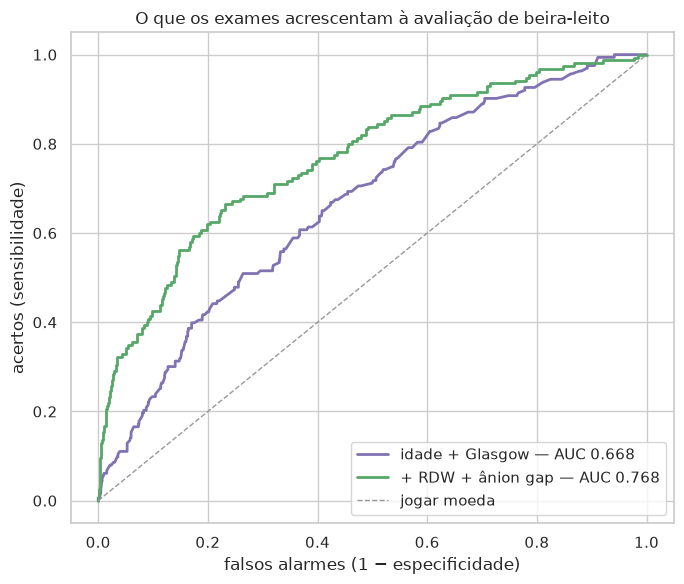

In [20]:
# As curvas ROC dos dois modelos, para visualizar a diferença.
fig, eixo = plt.subplots(figsize=(7, 6))
for colunas, rotulo, cor in [
    (REFERENCIA, "idade + Glasgow", "#8172b2"),
    (PARCIMONIOSO, "+ RDW + ânion gap", "#55a868"),
]:
    dados = X[colunas + [OUTCOME]].dropna()
    y = dados[OUTCOME].astype(int)
    modelo = LogisticRegression(max_iter=2000).fit(dados[colunas].astype(float), y)
    risco = modelo.predict_proba(dados[colunas].astype(float))[:, 1]
    fpr, tpr, _ = roc_curve(y, risco)
    eixo.plot(
        fpr, tpr, color=cor, linewidth=2, label=f"{rotulo} — AUC {roc_auc_score(y, risco):.3f}"
    )
eixo.plot([0, 1], [0, 1], "--", color="#999", linewidth=1, label="jogar moeda")
eixo.set_xlabel("falsos alarmes (1 − especificidade)")
eixo.set_ylabel("acertos (sensibilidade)")
eixo.set_title("O que os exames acrescentam à avaliação de beira-leito")
eixo.legend(loc="lower right")
plt.tight_layout()
plt.show()

> **Como ler este gráfico.** Cada ponto da curva é um limiar de risco diferente. Quanto mais a curva se afasta da diagonal tracejada, melhor o modelo separa quem vai falecer de quem vai sobreviver.
>
> A curva verde fica acima da roxa em quase toda a extensão, e a distância é maior no canto esquerdo. Esse canto é onde a decisão clínica costuma operar: identificar os pacientes de risco alto sem disparar alarme para a unidade inteira.
>
> Atenção: estas curvas foram calculadas nos mesmos pacientes usados para treinar, então ficam um pouco otimistas. Os números das tabelas anteriores, que usam validação cruzada, são os confiáveis.

## 6 Verificações

Um resultado que só aparece sob uma escolha específica não é resultado. A Entrega 1 se comprometeu com algumas verificações, e a pergunta em todas é a mesma: **algum veredicto muda?**

### 6.1 E se preenchêssemos os valores que faltam?

Na análise principal, cada modelo usa só os pacientes com todos os exames. Uma alternativa é preencher o que falta com a mediana. Se o resultado mudar muito entre as duas abordagens, o veredicto depende dessa escolha e não do exame.

In [21]:
PARA_VERIFICAR = ["Anion Gap", "RDW", "Urea Nitrogen", "Systolic BP", "Creatinine"]

# Cria uma cópia da tabela preenchendo os buracos com a mediana de cada coluna.
X_preenchido = X.copy()
for coluna in PARA_VERIFICAR + REFERENCIA:
    X_preenchido[coluna] = X_preenchido[coluna].fillna(X_preenchido[coluna].median())

verificacao_ausentes = pd.DataFrame(
    [
        {
            "candidato": c,
            "ganho (só casos completos)": ganho_do_candidato(X, c)["ganho"],
            "ganho (preenchido)": ganho_do_candidato(X_preenchido, c)["ganho"],
        }
        for c in PARA_VERIFICAR
    ]
)
verificacao_ausentes["diferença"] = (
    verificacao_ausentes["ganho (preenchido)"] - verificacao_ausentes["ganho (só casos completos)"]
).round(4)
verificacao_ausentes

,candidato,ganho (só casos completos),ganho (preenchido),diferença
0,Anion Gap,0.072,0.077,0.005
1,RDW,0.080,0.070,-0.010
2,Urea Nitrogen,0.037,0.032,-0.005
3,Systolic BP,0.027,0.031,0.004
4,Creatinine,0.016,0.018,0.002


> **O que isso mostra.** As diferenças são pequenas e nenhum candidato muda de lado. Isso é tranquilizador: os resultados não são um efeito de ter descartado pacientes incompletos.
>
> Uma ressalva honesta: preencher com a mediana é uma escolha conservadora. Ela empurra os valores ausentes para o meio da distribuição, o que tende a enfraquecer qualquer efeito em vez de criar um. Então o teste mostra que não inventamos nada, mas não resolve o problema de a ausência ter significado clínico.

### 6.2 O ânion gap corrigido pela albumina

A albumina é uma proteína que "esconde" parte da acidez do sangue. Quando ela está baixa, o ânion gap medido subestima o problema real. Existe uma fórmula usada na prática para corrigir isso, e a Entrega 1 pediu que a testássemos.

Só dá para calcular em quem teve albumina dosada, que é menos de um terço da coorte.

In [22]:
com_albumina = X[X.Albumin.notna()]
print(
    f"pacientes com albumina dosada: {len(com_albumina)} "
    f"({len(com_albumina) / len(X):.1%} da coorte)"
)

verificacao_albumina = pd.DataFrame(
    [ganho_do_candidato(com_albumina, c) for c in ["Anion Gap", "anion_gap_corrigido"]]
)
verificacao_albumina

pacientes com albumina dosada: 287 (28.7% da coorte)


,candidato,n,AUC sem,AUC com,ganho
0,Anion Gap,287,0.691,0.710,0.019
1,anion_gap_corrigido,287,0.691,0.739,0.048


> **O que isso mostra.** Nos mesmos pacientes, o ânion gap corrigido rende mais que o bruto. A correção prevista na Entrega 1 não era formalidade: ela recupera um sinal que a medida sem correção perde.
>
> Duas ressalvas seguram o entusiasmo. O grupo é pequeno, e é um grupo selecionado, porque a albumina só foi pedida em quem o médico achou necessário. E o ânion gap bruto já funciona bem na coorte inteira, onde o corrigido nem pode ser calculado. A conclusão prática: o ânion gap continua como candidato na forma simples, e a correção entra na Entrega 3 como refinamento a testar.

### 6.3 Duas conferências que a Entrega 1 pediu

A primeira testa se a razão ureia/creatinina mede o que dizia medir. O argumento da Entrega 1 era que ela refletiria a ação de um hormônio que retém água. Se isso fosse verdade, ela deveria andar junto com o sódio baixo, porque esse mesmo hormônio dilui o sódio.

A segunda olha a origem da medida de pressão. A Entrega 1 supôs que o cateter arterial fosse sinal de gravidade, já que é colocado em quem o médico considera mais grave.

In [23]:
# Conferência 1: a razão anda junto com o sódio, como a teoria previa?
dados = X[["razao_ureia_creatinina", "Sodium"]].dropna()
correlacao_sodio = dados.corr(method="spearman").iloc[0, 1]
print("razão ureia/creatinina e sódio")
print(f"  correlação: {correlacao_sodio:+.3f}  (em {len(dados)} internações)")
print("  se a razão medisse retenção de água pelo hormônio, esperaríamos correlação negativa")
print()

# Conferência 2: como o método de medir a pressão se relaciona com o desfecho?
print("de onde veio a primeira medida de pressão")
print(
    X.dropna(subset=["origem_pressao"])
    .groupby("origem_pressao")
    .agg(internacoes=(OUTCOME, "size"), mortalidade=(OUTCOME, lambda s: f"{s.mean():.1%}"))
    .to_string()
)

razão ureia/creatinina e sódio
  correlação: +0.093  (em 982 internações)
  se a razão medisse retenção de água pelo hormônio, esperaríamos correlação negativa

de onde veio a primeira medida de pressão
                internacoes mortalidade
origem_pressao                         
invasiva                200       11.5%
nao invasiva            792       17.3%


> **O que isso mostra.** As duas conferências contrariam o que a Entrega 1 supunha, e as duas informam.
>
> A correlação entre a razão ureia/creatinina e o sódio é praticamente **zero, e no sinal errado**. Isso explica *por que* a razão falhou, e não apenas *que* falhou: ela não está medindo o mecanismo hormonal que a justificava. Um candidato que falha por não medir o que prometia é um resultado mais útil do que um candidato que simplesmente não deu significância.
>
> A origem da pressão surpreende mais. Quem teve cateter arterial teve mortalidade **menor**, não maior. É o inverso do esperado. Uma explicação plausível é que o cateter acompanhe cirurgias programadas e pacientes vigiados de perto, em vez de acompanhar deterioração clínica. Como esta etapa é descritiva, isso fica como hipótese, mas a recomendação prática é clara: a origem da medida precisa acompanhar a pressão nos modelos da Entrega 3, porque ela carrega informação que não é hemodinâmica.

### 6.4 E se não tivéssemos limitado os extremos?

A seção 1.3 limitou os valores nos percentis 1 e 99. Foi uma escolha nossa, e toda escolha precisa ser testada: se um candidato só se sustenta com o tratamento, o que está sendo medido é o tratamento e não o exame.

Aqui refazemos os candidatos a partir das tabelas originais, guardadas antes do tratamento, e comparamos o ganho de cada um nas duas versões.

In [24]:
# Refaz as colunas dos candidatos a partir das tabelas originais, sem limite.
painel_original = labs_original.pivot(index="paciente_id", columns="exame", values="valor")
vitais_primeiro_original = primeiro_valor(vitais_original, "sinal")

X_sem_limite = X.copy()
for exame in EXAMES_CANDIDATOS:
    X_sem_limite[exame] = painel_original[exame]
for sinal in VITAIS_CANDIDATOS:
    X_sem_limite[sinal] = vitais_primeiro_original[sinal]

# As contas derivadas dependem dos valores, então precisam ser refeitas também.
X_sem_limite["razao_ureia_creatinina"] = X_sem_limite["Urea Nitrogen"] / X_sem_limite["Creatinine"]
X_sem_limite["razao_neutrofilos_linfocitos"] = X_sem_limite["Neutrophils"] / X_sem_limite[
    "Lymphocytes"
].where(X_sem_limite["Lymphocytes"] > 0)

verificacao_extremos = pd.DataFrame(
    [
        {
            "candidato": c,
            "ganho (com limite)": ganho_do_candidato(X, c)["ganho"],
            "ganho (sem limite)": ganho_do_candidato(X_sem_limite, c)["ganho"],
        }
        for c in CANDIDATOS
    ]
)
verificacao_extremos["diferença"] = (
    verificacao_extremos["ganho (sem limite)"] - verificacao_extremos["ganho (com limite)"]
).round(4)

# O veredicto de cada um nas duas versões, pelo mesmo critério da seção 5.2.
for coluna in ["com limite", "sem limite"]:
    verificacao_extremos[f"passa ({coluna})"] = verificacao_extremos[f"ganho ({coluna})"] >= 0.01
verificacao_extremos["mudou de lado"] = np.where(
    verificacao_extremos["passa (com limite)"] != verificacao_extremos["passa (sem limite)"],
    "SIM",
    "",
)

quantos_mudaram = (verificacao_extremos["mudou de lado"] == "SIM").sum()
print(
    f"candidatos que mudam de lado por causa do tratamento: {quantos_mudaram} de {len(CANDIDATOS)}"
)
print(f"maior diferença de ganho em módulo: {verificacao_extremos['diferença'].abs().max():.4f}")
verificacao_extremos.drop(columns=["passa (com limite)", "passa (sem limite)"])

candidatos que mudam de lado por causa do tratamento: 0 de 13
maior diferença de ganho em módulo: 0.0150


,candidato,ganho (com limite),ganho (sem limite),diferença,mudou de lado
0,Urea Nitrogen,0.037,0.036,-0.001,
1,razao_ureia_creatinina,0.002,0.001,-0.001,
2,Creatinine,0.016,0.014,-0.002,
3,RDW,0.080,0.080,0.000,
4,Anion Gap,0.072,0.072,0.000,
5,Bicarbonate,0.037,0.037,0.000,
6,Lactate,0.054,0.053,-0.001,
7,razao_neutrofilos_linfocitos,0.001,-0.014,-0.015,
8,Hemoglobin,-0.005,-0.005,0.000,
9,Sodium,0.000,-0.001,-0.001,


> **O que isso mostra.** **Nenhum dos treze candidatos muda de lado.** A maior diferença de ganho é 0,015, e em cinco candidatos, entre eles o RDW e o ânion gap que lideram o estudo, a diferença é exatamente zero. Nos demais fica em um ou dois milésimos. O tratamento não criou nem destruiu nenhum resultado.
>
> Vale explicar a única diferença que chama atenção, porque ela não é sobre extremos. A **razão neutrófilos/linfócitos** vai de −0,014 para +0,001, e o motivo é mecânico: quatro pacientes tinham linfócitos registrados como 0%, e dividir por zero deixava esses quatro fora da conta. Com o limite inferior em 0,8, eles passam a ter razão calculável e entram. Isso também explica por que o preenchimento da razão subiu de 38,2% para 38,6% na seção 2. O veredicto não muda: 0,001 continua muito abaixo do mínimo de um ponto.
>
> Há um efeito colateral a declarar com honestidade: limitar pelos percentis achata um pouco a amplitude e a variação dos exames repetidos, que são duas das características temporais da seção 3. Como a própria seção 5.3 mostrou que essas duas perdem para a média e o mínimo, isso não muda a leitura, mas é o tipo de consequência que precisa ficar registrada em vez de descoberta depois.
>
> A conclusão é simples: os resultados deste notebook não dependem do tratamento de extremos. Ele está aqui porque é a forma defensável de lidar com valores muito altos sem descartar os pacientes mais graves, e não porque muda alguma coisa a nosso favor.

## 7 Comparação dos candidatos

O quadro abaixo reúne tudo: como cada candidato se saiu nas duas perguntas e qual o veredicto.

In [25]:
HIPOTESE = {
    "Urea Nitrogen": 1,
    "razao_ureia_creatinina": 1,
    "Creatinine": 1,
    "Sodium": 1,
    "Anion Gap": 2,
    "Bicarbonate": 2,
    "Lactate": 2,
    "RDW": 3,
    "razao_neutrofilos_linfocitos": 3,
    "Hemoglobin": 3,
    "Systolic BP": 5,
    "Heart Rate": 5,
    "Respiratory Rate": 5,
}

quadro_final = resultado.assign(
    hipotese=lambda d: d.candidato.map(HIPOTESE),
    veredicto=lambda d: np.where(d.sustentado, "sustentado", "não sustentado"),
).merge(comparacao[["candidato", "mediana sobreviveram", "mediana faleceram"]], on="candidato")[
    [
        "candidato",
        "hipotese",
        "n",
        "mediana sobreviveram",
        "mediana faleceram",
        "ganho",
        "separa os grupos",
        "melhora a previsão",
        "veredicto",
    ]
]

print("resumo do veredicto:")
print(quadro_final.veredicto.value_counts().to_string())
quadro_final.sort_values(["hipotese", "ganho"], ascending=[True, False])

resumo do veredicto:
veredicto
sustentado        8
não sustentado    5


,candidato,hipotese,n,mediana sobreviveram,mediana faleceram,ganho,separa os grupos,melhora a previsão,veredicto
4,Urea Nitrogen,1,980,27.00,37.00,0.037,True,True,sustentado
6,Creatinine,1,981,1.20,1.70,0.016,True,True,sustentado
8,razao_ureia_creatinina,1,980,20.00,21.65,0.002,False,False,não sustentado
10,Sodium,1,980,138.00,138.00,0.000,False,False,não sustentado
1,Anion Gap,2,977,14.00,17.00,0.072,True,True,sustentado
2,Lactate,2,630,1.80,2.10,0.054,True,True,sustentado
3,Bicarbonate,2,977,24.00,21.00,0.037,True,True,sustentado
0,RDW,3,970,15.10,16.50,0.080,True,True,sustentado
9,razao_neutrofilos_linfocitos,3,385,8.17,9.52,0.001,False,False,não sustentado
12,Hemoglobin,3,970,10.00,9.90,-0.005,False,False,não sustentado


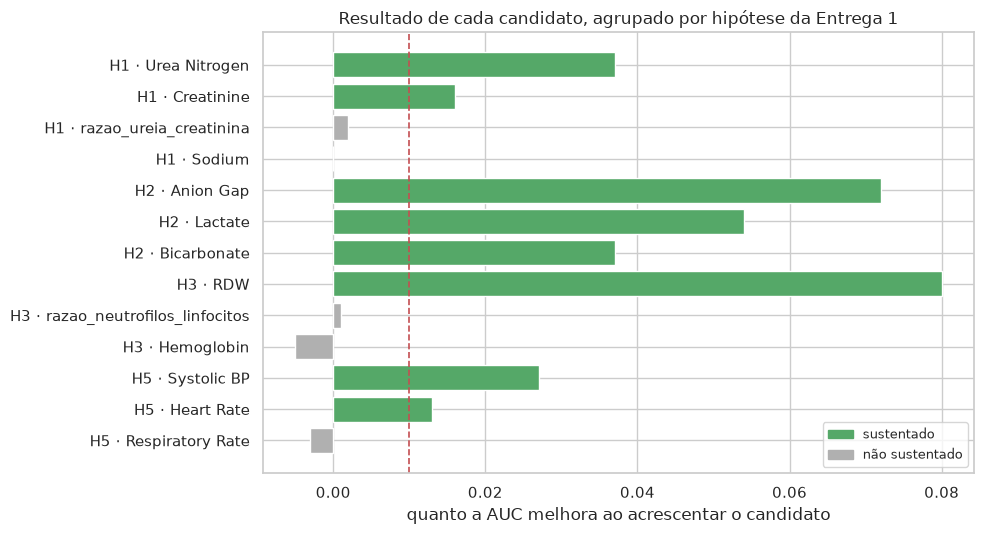

In [26]:
# O mesmo quadro em gráfico, agrupado por hipótese.
fig, eixo = plt.subplots(figsize=(10, 5.5))
d = quadro_final.sort_values(["hipotese", "ganho"], ascending=[True, False])
cores = np.where(d.veredicto == "sustentado", "#55a868", "#b0b0b0")
eixo.barh(np.arange(len(d)), d.ganho, color=cores)
eixo.axvline(0.01, color="#c44e52", linestyle="--", linewidth=1.2)
eixo.set_yticks(np.arange(len(d)))
eixo.set_yticklabels([f"H{h} · {c}" for h, c in zip(d.hipotese, d.candidato, strict=True)])
eixo.set_xlabel("quanto a AUC melhora ao acrescentar o candidato")
eixo.set_title("Resultado de cada candidato, agrupado por hipótese da Entrega 1")
eixo.invert_yaxis()
eixo.legend(
    handles=[
        plt.matplotlib.patches.Patch(color="#55a868", label="sustentado"),
        plt.matplotlib.patches.Patch(color="#b0b0b0", label="não sustentado"),
    ],
    loc="lower right",
    fontsize=9,
)
plt.tight_layout()
plt.show()

> **O que isso mostra.** Agrupar por hipótese revela um padrão que a lista simples escondia: as hipóteses não se sustentam ou caem por inteiro.
>
> A **hipótese 2**, sobre acidez e má circulação, é a que se sai melhor: seus três candidatos passam.
>
> A **hipótese 3**, sobre inflamação, se sustenta por um único candidato. O RDW é o melhor de todos, mas os outros dois do mesmo grupo ficaram entre os piores.
>
> A **hipótese 1**, sobre função renal, tem resultado misto: ureia e creatinina passam, mas a razão entre elas e o sódio não.

## 8 Evidência computacional preliminar

Esta seção é o produto final do notebook. Ela responde à pergunta da Entrega 2: **os dados sustentam as hipóteses da Entrega 1?**

In [27]:
# Monta o resumo final: o que entra na Entrega 3 e o que fica para trás.
evidencia = pd.DataFrame(
    [
        {
            "candidato": linha.candidato,
            "hipótese": linha.hipotese,
            "veredicto": linha.veredicto,
            "por quê": (
                f"separa os grupos (mediana {linha['mediana sobreviveram']} contra "
                f"{linha['mediana faleceram']}) e melhora a previsão em "
                f"{linha.ganho:.3f} de AUC"
                if linha.veredicto == "sustentado"
                else (
                    f"melhora a previsão só {linha.ganho:.3f}, abaixo do mínimo de 0,010"
                    if linha["separa os grupos"]
                    else "não separa os grupos nem melhora a previsão"
                )
            ),
        }
        for _, linha in quadro_final.iterrows()
    ]
).sort_values(["hipótese", "veredicto"])

print(f"sustentados: {(evidencia.veredicto == 'sustentado').sum()} de {len(evidencia)}")
print("candidato J (congestão radiográfica): suspenso, sem radiografia nesta coorte")
evidencia

sustentados: 8 de 13
candidato J (congestão radiográfica): suspenso, sem radiografia nesta coorte


,candidato,hipótese,veredicto,por quê
8,razao_ureia_creatinina,1,não sustentado,não separa os grupos nem melhora a previsão
10,Sodium,1,não sustentado,não separa os grupos nem melhora a previsão
4,Urea Nitrogen,1,sustentado,separa os grupos (mediana 27.0 contra 37.0) e ...
6,Creatinine,1,sustentado,separa os grupos (mediana 1.2 contra 1.7) e me...
1,Anion Gap,2,sustentado,separa os grupos (mediana 14.0 contra 17.0) e ...
2,Lactate,2,sustentado,separa os grupos (mediana 1.8 contra 2.1) e me...
3,Bicarbonate,2,sustentado,separa os grupos (mediana 24.0 contra 21.0) e ...
9,razao_neutrofilos_linfocitos,3,não sustentado,não separa os grupos nem melhora a previsão
12,Hemoglobin,3,não sustentado,não separa os grupos nem melhora a previsão
0,RDW,3,sustentado,separa os grupos (mediana 15.1 contra 16.5) e ...


### 8.1 Veredicto por hipótese

**Hipótese 1 — função renal.** *Parcialmente sustentada.* A ureia e a creatinina separam os grupos e melhoram a previsão, e o corte de 43 mg/dL do ADHERE se confirma nesta coorte. Mas a hipótese dizia que a **razão** ureia/creatinina carregaria informação além do que cada exame traz sozinho, e isso não aconteceu: ela foi um dos piores candidatos. Pior ainda, a conferência da seção 6.3 mostrou que ela nem mede o mecanismo hormonal que a justificava. O sódio, incluído na mesma hipótese, também falhou. Sobrevive a função renal como marcador; não sobrevive o raciocínio que a Entrega 1 construiu em cima dela.

**Hipótese 2 — acidez e má circulação.** *Sustentada.* É a hipótese mais bem-sucedida das cinco. Ânion gap, bicarbonato e lactato passam nas duas perguntas, e o ânion gap é o segundo melhor candidato geral. A correção pela albumina melhora ainda mais o resultado onde pode ser calculada.

**Hipótese 3 — inflamação.** *Parcialmente sustentada.* O **RDW é o melhor candidato de todos**, o que sustenta a hipótese. Mas os outros dois marcadores do mesmo eixo caíram: a hemoglobina teve ganho praticamente nulo e a razão neutrófilos/linfócitos não separou os grupos, além de existir em apenas 38% da coorte. O eixo inflamatório se sustenta por um marcador só.

**Hipótese 4 — congestão na radiografia.** *Não testável.* Continua sem dado de imagem, como a Entrega 1 já registrava.

**Hipótese 5 — instabilidade circulatória.** *Parcialmente sustentada.* A pressão sistólica passa, e o corte de 115 mmHg do ADHERE se confirma. A frequência cardíaca também passa, com ganho menor. A frequência respiratória não passa. E a seção 6.3 acrescenta um alerta: a forma de medir a pressão carrega informação que não é sobre a circulação do paciente.